# 02_MA_Refinement
## Xiaonan Wang
## 20Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [2]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [ ]:
sc.logging.print_header()

In [75]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

In [4]:
x_myeloid = sc.read_h5ad(datadir + "myeloid_xenium.h5ad")

In [5]:
MA = x_myeloid[x_myeloid.obs['celltype_final'] == 'Macrophages'].copy()

In [6]:
MA

AnnData object with n_obs × n_vars = 33375 × 389
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'donor_id', 'core_id', 'tma_id', 'age', 'pmi', 'sex', 'tissue_annotation', 'tech', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'celltype_final', 'age_category'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'features'
    uns: 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

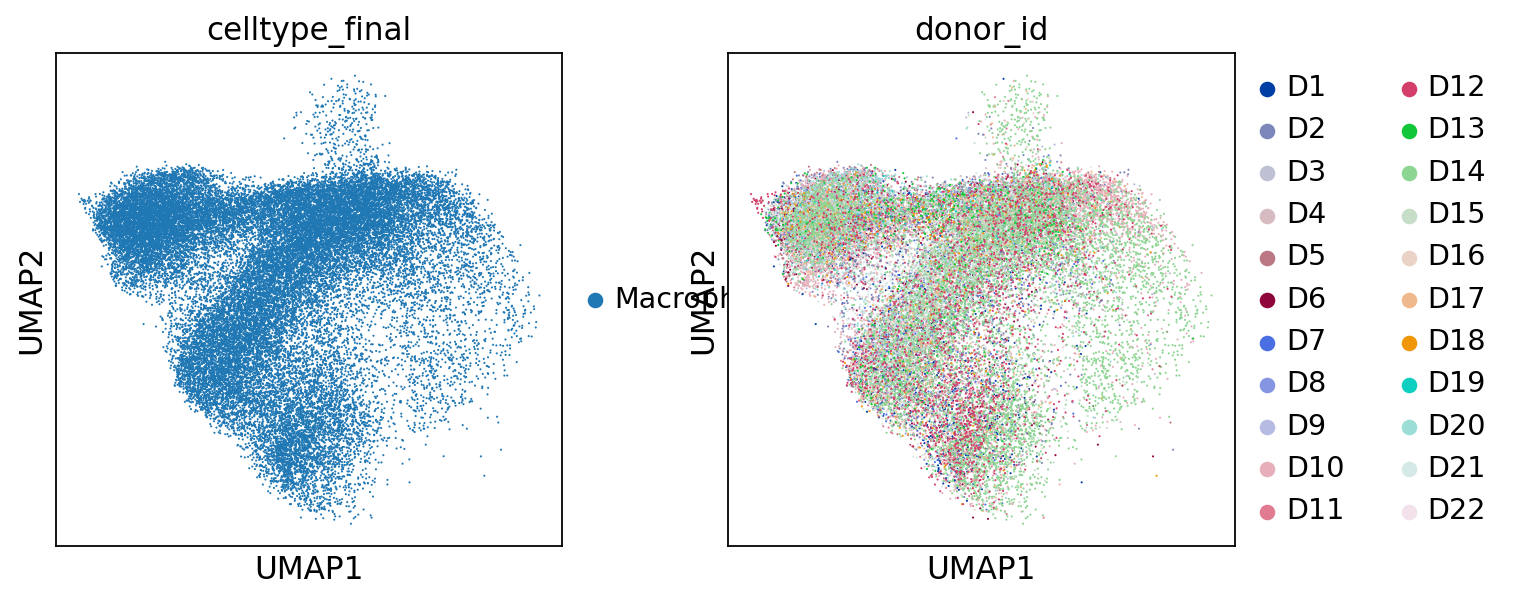

In [8]:
sc.pl.umap(MA, color=['celltype_final', 'donor_id'])

In [12]:
sc.tl.pca(
    MA,
    n_comps=30,
    svd_solver="arpack"
)

computing PCA
    with n_comps=30
    finished (0:00:00)


In [17]:
import scanpy.external as sce
import harmonypy as hm

In [18]:
ho = hm.run_harmony(
    MA.obsm["X_pca"],
    MA.obs,
    vars_use="donor_id",
    random_state=0,
)

2026-09-20 14:13:23,562 - harmonypy - INFO - Running Harmony
2026-09-20 14:13:23,563 - harmonypy - INFO -   Parameters:
2026-09-20 14:13:23,563 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-20 14:13:23,563 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-20 14:13:23,563 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-20 14:13:23,564 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-20 14:13:23,564 - harmonypy - INFO -     nclust: 100
2026-09-20 14:13:23,564 - harmonypy - INFO -     block_size: 0.05
2026-09-20 14:13:23,564 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-20 14:13:23,565 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-09-20 14:13:23,565 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-20 14:13:23,565 - harmonypy - INFO -     verbose: True
2026-09-20 14:13:23,565 - harmonypy - INFO -     random_state: 0
2026-09-20 14:13:23,566 - harmonypy - INFO -   Data: 30 PCs × 33

In [19]:
Z_corr = np.asarray(ho.Z_corr)

print("Harmony output:", Z_corr.shape)

Harmony output: (33375, 30)


In [20]:
if Z_corr.shape[0] == MA.n_obs:
    # current harmonypy: cells × PCs
    MA.obsm["X_pca_harmony"] = Z_corr

elif Z_corr.shape[1] == MA.n_obs:
    # older harmonypy: PCs × cells
    MA.obsm["X_pca_harmony"] = Z_corr.T

else:
    raise ValueError(
        f"Unexpected Harmony shape {Z_corr.shape}; "
        f"expected one dimension to equal n_obs={MA.n_obs}"
    )

print(MA.obsm["X_pca_harmony"].shape)

(33375, 30)


In [22]:
sc.pp.neighbors(
    MA,
    n_neighbors=20,
    n_pcs=20,
    use_rep="X_pca_harmony",
    metric="euclidean"
)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)


In [23]:
sc.tl.umap(
    MA,
    min_dist=0.3,
    random_state=0,
)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:28)


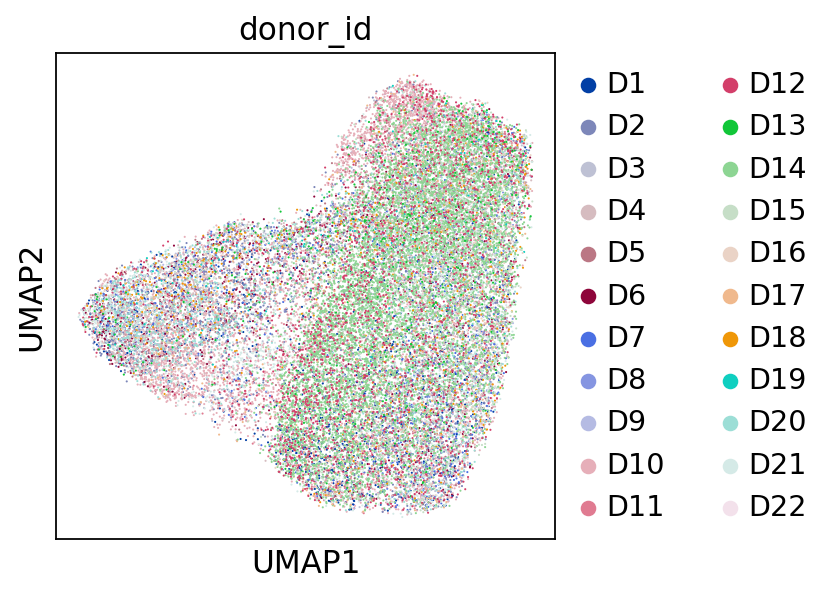

In [24]:
sc.pl.umap(MA, color='donor_id')

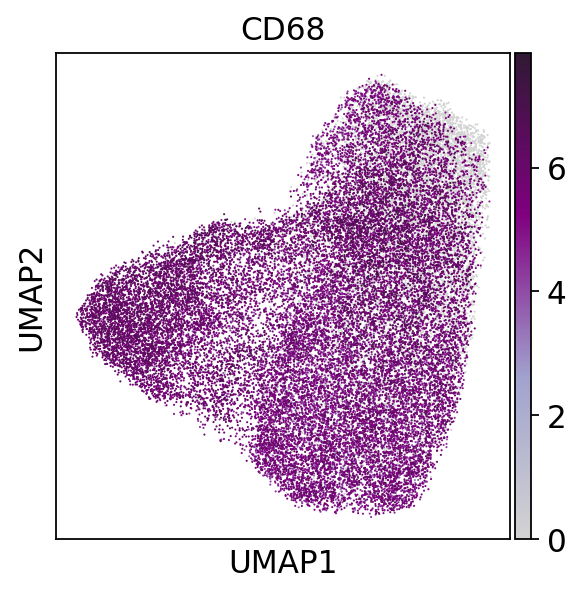

In [113]:
sc.pl.umap(MA, color=['CD68'], color_map=cmap, use_raw=False)

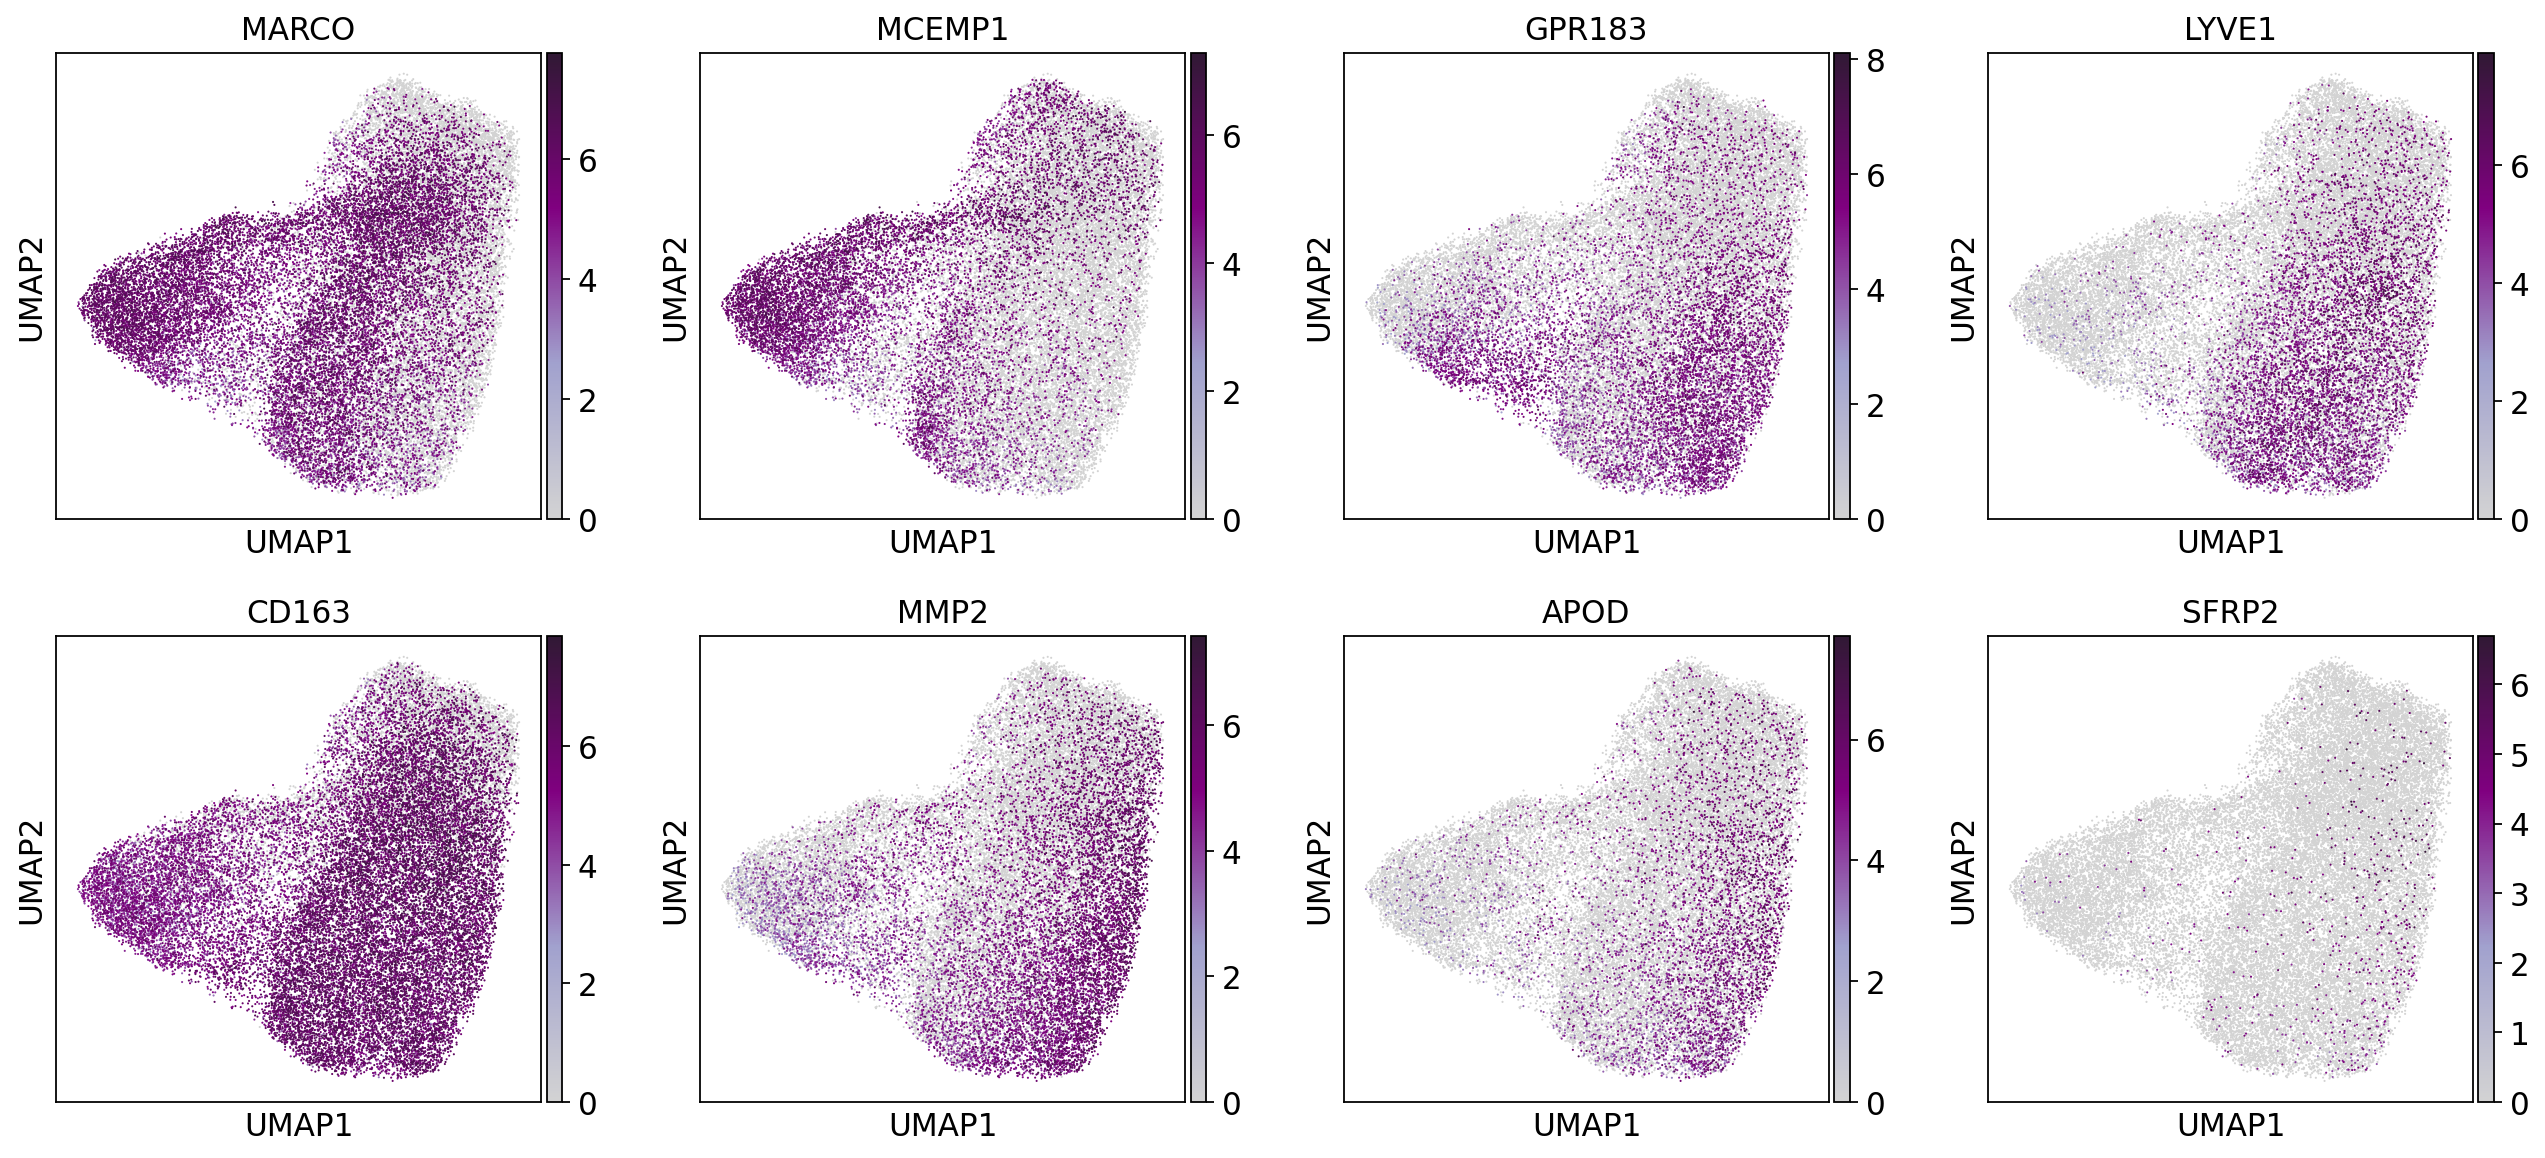

In [51]:
sc.pl.umap(MA, color=['MARCO', 'MCEMP1', 
                     "GPR183",
    "LYVE1",
    "CD163",
    "MMP2",
    "APOD",
    "SFRP2",], color_map=cmap, use_raw=False)

In [40]:
sc.tl.leiden(
    MA,
    resolution=1.2,
    key_added="Leiden_MA",
    random_state=0,
)

running Leiden clustering
    finished: found 11 clusters and added
    'Leiden_MA', the cluster labels (adata.obs, categorical) (0:00:17)


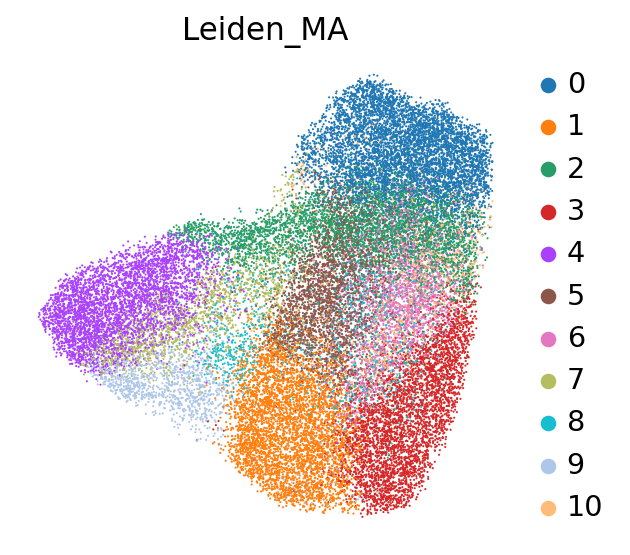

In [41]:
sc.pl.umap(
    MA,
    color=[
        "Leiden_MA",
    ],
    ncols=3,
    frameon=False,
)

In [44]:
sc.tl.rank_genes_groups(MA, groupby='Leiden_MA', n_genes=x_myeloid.shape[1], method='wilcoxon', key_added='DE_Leiden_MA')

ranking genes
    finished: added to `.uns['DE_Leiden_MA']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


In [45]:
pd.DataFrame(MA.uns['DE_Leiden_MA']['names']).head(50)

,0,1,2,3,4,5,6,7,8,9,10
0,CXCL8,CD300E,FN1,MMP2,CD74,CD300E,LYVE1,CCL4,APOE,APOE,SERPINE1
1,PI3,LILRB2,AGER,IGFBP7,CD68,SPP1,FOS,CD44,SPP1,TYROBP,CCL2
2,CCL3,CD14,SFTPD,GPR183,MARCO,CXCL8,AREG,CXCL8,SLC1A3,CD68,ICAM1
3,CCL4,ITGAM,WIF1,CD163,MCEMP1,CD14,CD163,CCL3,GPR183,MS4A4A,CXCL8
4,S100A12,CD163,CEACAM6,FN1,HLA-DQB1,MARCO,GPR183,ICAM1,CD68,GPR183,FN1
5,CXCR4,VSIR,PEBP4,CXCL12,VSIG4,CXCL5,ADAM28,IL1B,PLA2G7,HMGB1,MMP2
6,SELENOH,AIF1,CHIT1,LTBP2,TYROBP,CD163,CD300E,CXCL2,MS4A4A,CD44,IL6
7,IL1B,MPEG1,DAPK2,MS4A4A,FCGR3A,ITGAM,APOD,CXCL5,CHIT1,PLAUR,IGFBP7
8,PLAU,HLA-E,GKN2,CD14,CD44,CTSL,PLA2G2A,CD68,CXCR4,HIF1A,CXCL2
9,SELL,CTSL,DMBT1,CD74,APOE,ANPEP,CLEC10A,CD47,ANXA1,ANXA1,NFKB1


In [52]:
AM_genes = [
    "MARCO",
    "MCEMP1",
]

IM_genes = [
    "GPR183",
    "LYVE1",
    "CD163",
    "MMP2",
    "APOD",
    "SFRP2",
]

MonoIM_genes = [
    "CD14",
    "FCN1",
    "CD300E",
    "ITGAM",
    "LILRB2",
    "LILRA5",
]

In [53]:
AM_genes_use = [g for g in AM_genes if g in MA.var_names]
IM_genes_use = [g for g in IM_genes if g in MA.var_names]

print("AM:", AM_genes_use)
print("IM:", IM_genes_use)

AM: ['MARCO', 'MCEMP1']
IM: ['GPR183', 'LYVE1', 'CD163', 'MMP2', 'APOD', 'SFRP2']


In [57]:
MA = score_and_assign_two_signatures(
    adata=MA,

    gene_list_1=AM_genes_use,
    gene_list_2=IM_genes_use,

    score_name_1="AM_score",
    score_name_2="IM_score",
    output_col="MA_group",

    label_1="AM",
    label_2="IM",
    ambiguous_label="Ambiguous",

    use_raw=True,
    layer=None,

    scale=True,
    max_value=10,
    zero_center=True,

    ambiguous=False,
    ambiguous_threshold=0,

    ctrl_size=50,
    n_bins=25,
    random_state=0,

    make_categorical=True,
    verbose=True,
)

Expression source: adata.raw

AM_score: 2/2 genes found

IM_score: 6/6 genes found

Scaling expression (max_value=10, zero_center=True)...
computing score 'AM_score'


/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/miniconda3/envs/scrna/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished: added
    'AM_score', score of gene set (adata.obs).
    30 total control genes are used. (0:00:00)
computing score 'IM_score'
    finished: added
    'IM_score', score of gene set (adata.obs).
    74 total control genes are used. (0:00:00)

Score summary:
           AM_score      IM_score
count  33375.000000  33375.000000
mean      -0.000069     -0.000315
std        0.635780      0.450713
min       -3.076991     -1.672122
25%       -0.244570     -0.204800
50%       -0.067459     -0.089411
75%        0.106448      0.090834
max        6.704318      5.617842

MA_group:
              n    percent
MA_group                  
AM        17116  51.283895
IM        16259  48.716105


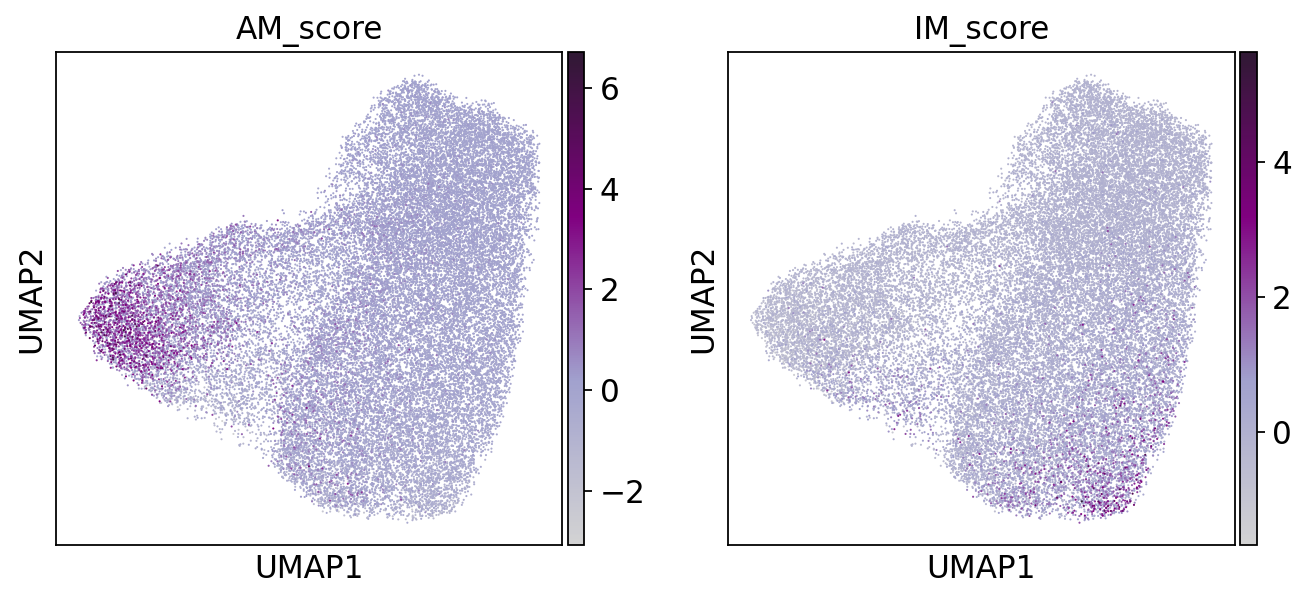

In [58]:
sc.pl.umap(MA, color=['AM_score', 'IM_score'], color_map=cmap)

In [108]:
palette = {
        "AM": "#E5B3D2",
        "IM": "#A85F82",
}

In [109]:
MA.uns['MA_group_colors'] = [palette[x] for x in MA.obs['MA_group'].cat.categories]

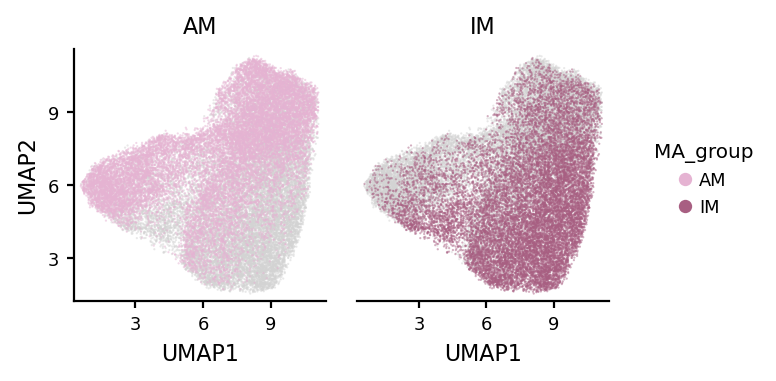

In [110]:
fig, axes = plot_anndata_group_umap(
    MA,
    group_col="MA_group",
    split_by="MA_group",
    split_categories=[
        "AM",
        "IM"
    ],
    point_size=1,
    point_alpha=0.5,
    width_cm=4,
    height_cm=4,
    top_cm=0.9,
    shared_limits=True,
    rasterized=True,
    legend_ncol=1,
    legend_width_cm=4.0
)

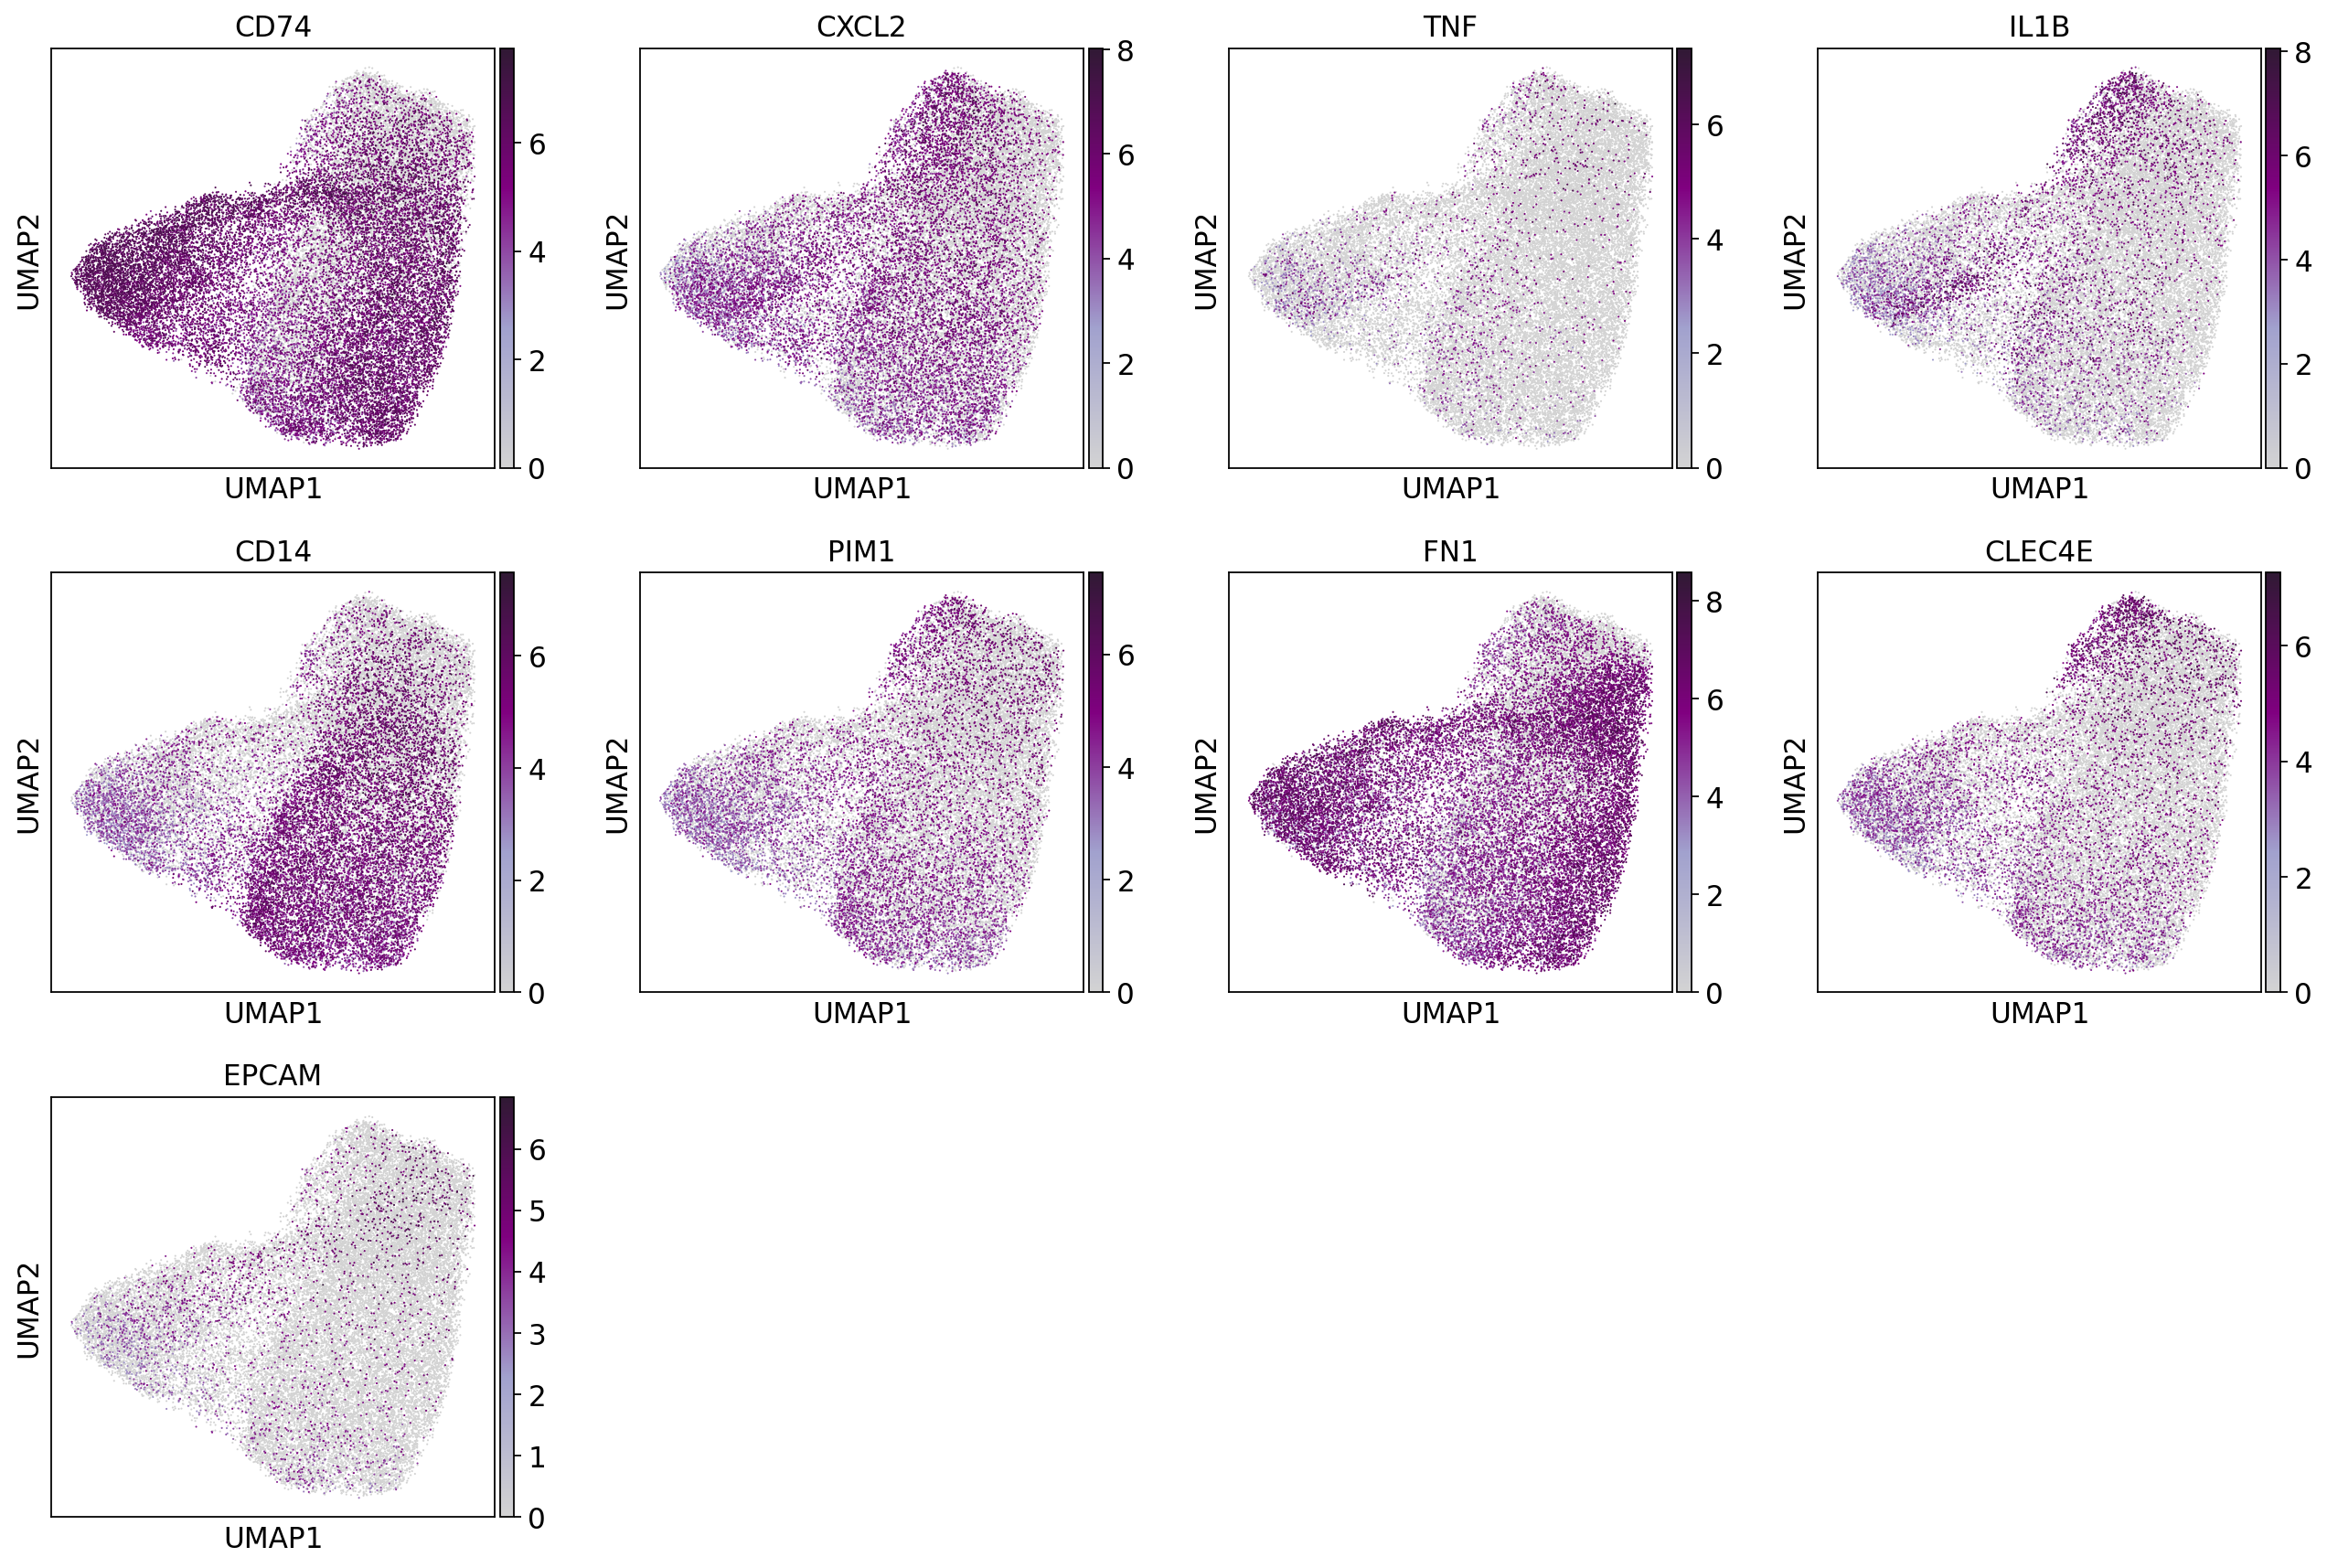

In [66]:
sc.pl.umap(MA, color=['CD74', 'CXCL2', 'TNF', 'IL1B', 'CD14', 'PIM1', 'FN1', 'CLEC4E', 'EPCAM'], color_map=cmap, use_raw=False)

In [77]:
x_all = sc.read_h5ad(datadir + "xenium.h5ad")

In [78]:
core_cols = ["donor_id", "tma_id", "core_id"]

macrophage_order = [
    "AM",
    "IM",
]

In [80]:
all_core_summary = (
    x_all.obs
    .assign(
        tissue_annotation=lambda d:
            d["tissue_annotation"]
            .astype("object")
            .fillna("None")
            .astype(str)
    )
    .groupby(
        core_cols + ["tissue_annotation"],
        observed=True,
    )
    .size()
    .rename("n_all_cells")
    .reset_index()
)

In [82]:
myeloid_obs = MA.obs.copy()

myeloid_obs["MA_group"] = (
    myeloid_obs["MA_group"]
    .astype("object")
)

myeloid_obs["tissue_annotation"] = (
    myeloid_obs["tissue_annotation"]
    .astype("object")
    .fillna("None")
    .astype(str)
)

macrophage_counts = (
    myeloid_obs[
        myeloid_obs["MA_group"].isin(macrophage_order)
    ]
    .groupby(
        core_cols + ["tissue_annotation", "MA_group"],
        observed=True,
    )
    .size()
    .rename("n_macrophage_cells")
    .reset_index()
)

In [92]:
complete_grid = (
    all_core_summary[
        core_cols + ["tissue_annotation", "n_all_cells"]
    ]
    .assign(_key=1)
    .merge(
        pd.DataFrame({
            "MA_group": macrophage_order,
            "_key": 1,
        }),
        on="_key",
    )
    .drop(columns="_key")
)

In [93]:
macrophage_abundance_pct_long = (
    complete_grid
    .merge(
        macrophage_counts,
        on=core_cols + ["tissue_annotation", "MA_group"],
        how="left",
    )
)

macrophage_abundance_pct_long["n_macrophage_cells"] = (
    macrophage_abundance_pct_long["n_macrophage_cells"]
    .fillna(0)
)

macrophage_abundance_pct_long["percent_of_all_cells"] = (
    100
    * macrophage_abundance_pct_long["n_macrophage_cells"]
    / macrophage_abundance_pct_long["n_all_cells"]
)

macrophage_abundance_pct_long["MA_group"] = pd.Categorical(
    macrophage_abundance_pct_long["MA_group"],
    categories=macrophage_order,
    ordered=True,
)

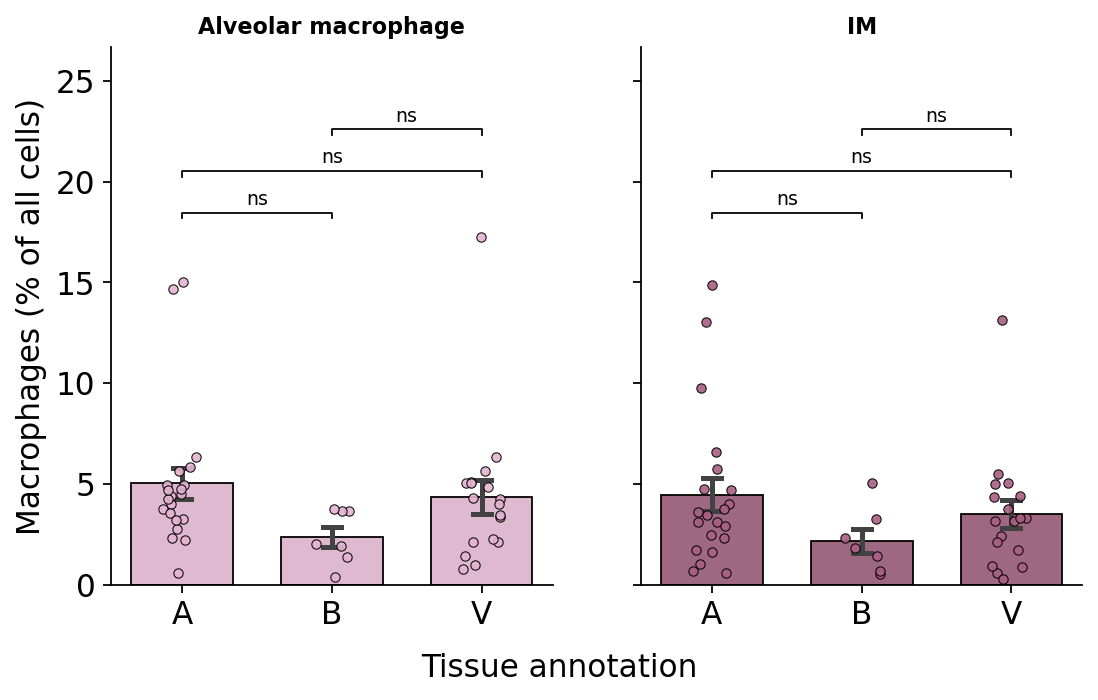

In [111]:
fig, axes, macrophage_abundance_summary, macrophage_abundance_stats = (
    source.plot_macrophage_pct_by_tissue(
        macrophage_abundance_pct_long,
        tissue_order=("A", "B", "V"),
        comparisons=(
            ("A", "B"),
            ("A", "V"),
            ("B", "V"),
        ),
        macrophage_order=macrophage_order,
        celltype_col='MA_group',
        value_col="percent_of_all_cells",
        ylabel="Macrophages (% of all cells)",
        palette=palette,
        save="Macrophage_abundance_pct_by_tissue.pdf",
    )
)

In [112]:
MA.write(outdir + 'MA.h5ad')